# <font color='red'>Classification (part 1)</font>

The task is to teach a machine how to learn to recognize hand-written digits (MNIST).

# **Practice C1**: Set-up

In [1]:
#numpy
import numpy as np
#sklearn
import sklearn
# matplotlib
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt

# **Practice C2**: Import the data

In [2]:
from tensorflow.keras.datasets import mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# **Practice C3**: Inspect the dataset

Familiarize a bit with the shapes of X and y.

In [3]:
X_train.shape

(60000, 28, 28)

In [4]:
X_test.shape

(10000, 28, 28)

In [5]:
y_train.shape

(60000,)

In [6]:
y_test.shape

(10000,)

If you  want to use it with sklearn or standard classifiers (as we are doing now), it is convenient to flatten the images.

In [7]:
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

In [8]:
X_train.shape

(60000, 784)

In [9]:
X_test.shape

(10000, 784)

NOTE: this is not necessary for $y$.

Now, explore your dataset.

In [10]:
X_train[0]

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,  18,  18,
       126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,  30,  36,  94, 154, 17

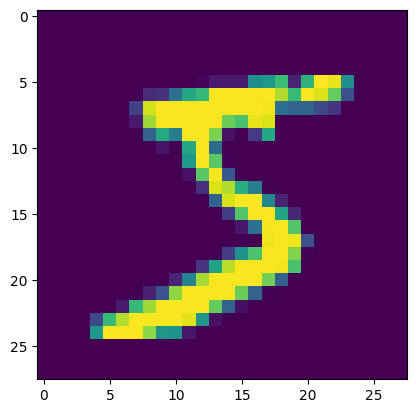

In [11]:
some_digit = X_train[0]
some_digit_image = some_digit.reshape(28, 28)
plt.imshow(some_digit_image)

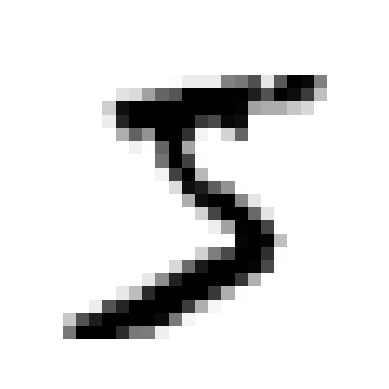

In [14]:
some_digit = X_train[0]
some_digit_image = some_digit.reshape(28, 28)
plt.imshow(some_digit_image, cmap = mpl.cm.binary, interpolation="nearest")
plt.axis("off")
plt.show()


As expected, the label for this is:

In [ ]:
y_train[0]

I will only handle numbers, so good to check it is not a string.

# **Practice C4**: Build a binary classifier: a "5-detector"

Create the label vectors (for both the train and test set):

In [ ]:
y_train_5 = (y_train == 5)
y_test_5 = (y_test == 5)

In [ ]:
y_train_5.shape

In [ ]:
y_train

In [ ]:
y_train_5

In [ ]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(max_iter=1000, tol=1e-3, random_state=42)
sgd_clf.fit(X_train, y_train_5)

# note: hyperparameters set to future default values in future versions on sklearn.

Let's see on X_test, the first 100 hand-written digits, if I get some 5's, and if the model works.

In [ ]:
for i in range(100):
    print(f"y_test[{i}] = {y_test[i]}")

Let's check if the classifier we built above works for some examples:

In [ ]:
sgd_clf.predict([X_test[50]]) # this is a 6, so NOT a 5

In [ ]:
sgd_clf.predict([X_test[51]]) # this is a 3, so NOT a 5

In [ ]:
sgd_clf.predict([X_test[52]]) # this is a 5

In [ ]:
sgd_clf.predict([X_test[53]]) # this is a 5

But.. be careful...

In [ ]:
sgd_clf.predict([X_test[8]]) # this is a 5, but it fails!

So, on MOST cases, it works (good) - but sometimes it fails (it is expected..).

So, the actual question is: if (evidently!) not 100% accurate, how accurate is this model?

# **Practice C5**: Compute the accuracy

We opted for a train-test split, so most rapid is to ask for the score in this way:

In [ ]:
sgd_clf.score(X_test, y_test_5)

Actually, k-fold cross-validation would be similar or better - and would also allow you to get insight on its variance. Let's try it out.

Use `cross_val_score()` function in sklearn to evaluate your SGDClassifier model using k-fold cross-validation, with k=3, i.e. make k trainings: split the training set into k folds, train and make predictions and evaluate them on each fold using a model trained on the remaining folds.

In [ ]:
y_train_5 = (y_train == 5)
y_train_5.shape

In [ ]:
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy")

# this trigger the training of cv=3 models, so it might take a while to complete!

As expected (see above), k-fold cross-validation is similar or better - and shows me some insights on its variance.

But... *Really?! Such a high accuracy at first attempt?! Are you sure this is reliable?*

# **Practice C6**: Confusion matrix: looking for a better performance metrics

In [ ]:
from sklearn.model_selection import cross_val_predict

y_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)

# this trigger the training of cv=3 models, so it might take a while to complete!

In [ ]:
type(y_pred)

In [ ]:
y_pred.shape

In [ ]:
y_pred

In [ ]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_train_5, y_pred)

Other possible metrics are **precision** and **recall**, and often also the **F1** score:

In [ ]:
from sklearn.metrics import precision_score
precision_score(y_train_5, y_pred)

In [ ]:
from sklearn.metrics import recall_score
recall_score(y_train_5, y_pred)

In [ ]:
from sklearn.metrics import f1_score
f1_score(y_train_5, y_pred)

In [ ]:
#create an array with, de-facto, the class probabilities
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3,
                             method="decision_function")

In [ ]:
y_scores

In [ ]:
y_train_5

In [ ]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)

In [ ]:
def plot_roc_curve(fpr, tpr, label=None):
    plt.plot(fpr, tpr, linewidth=2, label=label)
    plt.plot([0, 1], [0, 1], 'k--') # dashed diagonal
    plt.axis([0, 1, 0, 1])
    plt.xlabel('False Positive Rate (Fall-Out)', fontsize=16)
    plt.ylabel('True Positive Rate (Recall)', fontsize=16)
    plt.grid(True)

plt.figure(figsize=(8, 6))
plot_roc_curve(fpr, tpr)
plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_train_5, y_scores)

The AUC score should result as roughly 96-97%, when comparing your work with others'. It is a good result!